# Scattering con indice cromatico sbagliato: α = 4.4 nella simulazione, α = 4.0 nell'analisi

Dati simulati in `Simulations.ipynb` (seed `jax.random.key(1)`, salvati in `sim_data_noise_sv44/`) con red noise + DM (α = 2) + scattering generato con **α = 4.4**, senza GWB, valori veri standard.

Li analizzo con il solito modello a 6 parametri, in cui lo scattering è modellato con **α = 4.0**. Confronto con `chain_sim` (stessa simulazione e stesso seed, ma scattering con α = 4.0): la differenza tra le due posterior è dovuta solo all'errata specificazione dell'indice cromatico.

## Setup comune

Copia delle celle 0, 1, 3, 4, 6, 7, 9 di `Likelihood.ipynb`.

In [2]:
import numpy as np
import os, glob, json
import pickle

import sys

# this is the path to the discovery folder
sys.path.insert(0, "./")
import discovery_new as ds

import matplotlib.pyplot as plt
import scipy
import jax.numpy as jnp

from scipy.stats import uniform
import re
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
from scipy.stats import uniform
import jax

import time
import emcee

Optional mpi4py package is not installed.  MPI support is not available.


In [5]:
# path to the folder with the data
path = './dati/DR2low_feathers/'
s_dsfiles = np.sort(os.listdir(path))
psr = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles][9] # we are only analysing pulsar #9

In [6]:
# data
model = [psr.residuals]
# timing model
model += [ds.makegp_timing(psr, svd=True)]
# white noise parameters
model += [ds.makenoise_measurement(psr, psr.noisedict, tnequad = True, ecorr=True)]
# red noise paramters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_red_components'], T=ds.getspan(psr), name='red_noise' ))
# DM variation parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_dm_components'], T=ds.getspan(psr), name='dm_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 2.0, tndm = False)))
# scattering noise parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_chrom_components'], T=ds.getspan(psr), name='sv_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 4.0, tndm = False)))

In [7]:
logL = ds.PulsarLikelihood(model).logL

In [9]:

# annoying function needed because the function logL want a dictionary as input, but our sampler wants a likelihood with an array as input
# so we have to switch from one to another :(
def params_dict_from_array(x):
    # ensure x is a plain numpy array before slicing
    x = np.asarray(x)
    return dict(zip(logL.params, x))

In [10]:
##### Cell for the prior distributions ###################################################################################

# dictionary with minimum and maximum value of the prior distribution
my_priordict = {}
my_priordict["(.*_)?sv_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?sv_gp_alpha.*"] = [0, 10]
my_priordict["(.*_)?sv_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_log10_A.*"] = [-10, 1]
my_priordict["(.*_)?sw_gamma.*"] = [-5, 6]
my_priordict["(.*_)?dm_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?dm_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?red_noise_gamma.*"] = [0, 7]
my_priordict["(.*_)?red_noise_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_n_earth.*"] = [0, 30]


def build_priors(param_names, priordict):
    """
    Build a {param_name: scipy dist} dict with uniform prior distributions in the range
    """
    priors = {}
    unmatched = []
    for name in param_names:
        matched = False
        for pattern, (lo, hi) in priordict.items():
            if re.fullmatch(pattern, name):
                priors[name] = uniform(loc=lo, scale=hi - lo) ## this is where the uniform distribution is defined
                matched = True
                break
        if not matched:
            unmatched.append(name)

    if unmatched:
        print(f"Warning: no prior found for {len(unmatched)} parameters, "
              f"falling back to standard normal:\n  {unmatched}")
    return priors

priors = build_priors(logL.params, my_priordict)
priors

def log_prior(x):
    """Compute log prior"""
    params = params_dict_from_array(x)
    
    logp = 0.0
    for name, value in params.items():
        if name in priors:
            logp += priors[name].logpdf(value)
        else:
            # Default: standard normal prior
            if isinstance(value, np.ndarray):
                logp += -0.5 * np.sum(value**2)
            else:
                logp += -0.5 * value**2
    
    return logp

def prior_draw():
    """Draw from prior and return as flat array"""
    x = []
    for name in logL.params:
        x.append(priors[name].rvs())
    return np.array(x)

x0 = prior_draw()
x0

array([  3.37603749, -17.75061805,   1.1669804 , -19.41032243,
         5.33202745, -12.70577943])

In [11]:
@jax.jit # compile the likelihood in jax to make it faster
def _jit_logL(params_array):
    params = dict(zip(logL.params, params_array))
    return logL(params)

_jit_logL(x0)

def log_likelihood(x): 
    """
    Likelihood function that is given to the samples, it uses the jitted (=faster) version of the likelihood
    """
    x = np.asarray(x, dtype=np.float64)
    result = _jit_logL(jnp.array(x))
    return float(np.array(result))  # always a plain Python float

## Catena di confronto (letta da disco, nessun sampling)

- `chain_sim`: simulazione senza GWB con scattering α = 4.0, stesso seed `key(1)` (cella 61 dell'originale)

In [12]:
chain_sim = np.loadtxt('./test_sim/chain_1.txt')[:, :-4]
chain_sim = chain_sim[len(chain_sim)//4:]
print('shape chain_sim:', chain_sim.shape)

shape chain_sim: (75001, 6)


## Dati simulati con scattering α = 4.4

In [9]:
sim_sv44_psr = ds.pulsar.Pulsar.read_feather('sim_data_noise_sv44/J1640+2224')
print('nome     :', sim_sv44_psr.name)
print('N_TOA    :', len(sim_sv44_psr.toas))
print('shape M  :', sim_sv44_psr.Mmat.shape)

nome     : J1640+2224
N_TOA    : 6777
shape M  : (6777, 39)


### Controllo: la simulazione è davvero diversa da quella con α = 4.0?

`sim_data_noise/` e `sim_data_noise_sv44/` sono generate con lo stesso seed e lo stesso modello, tranne l'α dello scattering. Quindi i residui devono essere **diversi** (altrimenti α = 4.4 non è stato usato), e la differenza deve crescere alle basse frequenze radio, perché lo scattering scala come (1400/ν)^α.

residui identici?         False
std residui alpha=4.0    : 8.292204526213539e-05
std residui alpha=4.4    : 8.117907680110985e-05
std differenza           : 1.680100469419565e-05


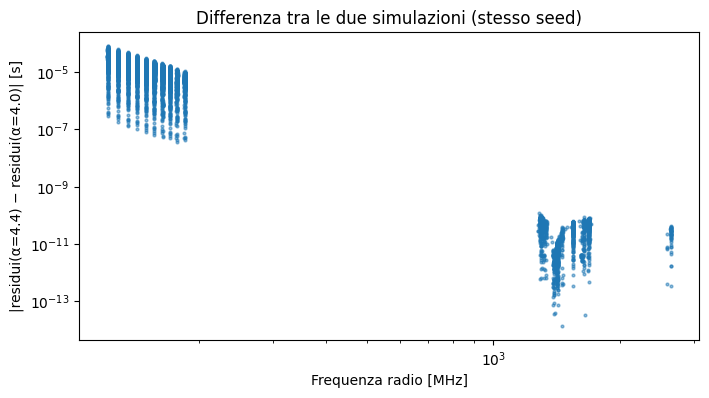

In [10]:
sim_psr_alpha4 = ds.pulsar.Pulsar.read_feather('sim_data_noise/J1640+2224')

diff = sim_sv44_psr.residuals - sim_psr_alpha4.residuals
print('residui identici?        ', np.allclose(sim_sv44_psr.residuals, sim_psr_alpha4.residuals))
print('std residui alpha=4.0    :', np.std(sim_psr_alpha4.residuals))
print('std residui alpha=4.4    :', np.std(sim_sv44_psr.residuals))
print('std differenza           :', np.std(diff))

plt.figure(figsize=(8, 4))
plt.scatter(sim_sv44_psr.freqs, np.abs(diff), s=4, alpha=0.5)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Frequenza radio [MHz]')
plt.ylabel('|residui(α=4.4) − residui(α=4.0)| [s]')
plt.title('Differenza tra le due simulazioni (stesso seed)')
plt.show()

## Analisi con il modello standard (scattering α = 4.0)

In [11]:
# stesso modello a 6 par dei dati reali: lo scattering è modellato con alpha = 4.0 (errato di proposito)
model_sim_sv44 = [sim_sv44_psr.residuals]
model_sim_sv44 += [ds.makegp_timing(sim_sv44_psr, svd=True)]
model_sim_sv44 += [ds.makenoise_measurement(sim_sv44_psr, sim_sv44_psr.noisedict, tnequad=True, ecorr=True)]
model_sim_sv44.append(ds.makegp_fourier(sim_sv44_psr, ds.powerlaw, sim_sv44_psr.noisedict[sim_sv44_psr.name + '_red_components'],
                                        T=ds.getspan(sim_sv44_psr), name='red_noise'))
model_sim_sv44.append(ds.makegp_fourier(sim_sv44_psr, ds.powerlaw, sim_sv44_psr.noisedict[sim_sv44_psr.name + '_dm_components'],
                                        T=ds.getspan(sim_sv44_psr), name='dm_gp',
                                        fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim_sv44.append(ds.makegp_fourier(sim_sv44_psr, ds.powerlaw, sim_sv44_psr.noisedict[sim_sv44_psr.name + '_chrom_components'],
                                        T=ds.getspan(sim_sv44_psr), name='sv_gp',
                                        fourierbasis=ds.make_dmfourierbasis(alpha=4.0, tndm=False)))   # <-- 4.0, non 4.4

logL_sim_sv44 = ds.PulsarLikelihood(model_sim_sv44).logL
logL_sim_sv44.params

['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [12]:
# controllo: stessi parametri e stesso ordine dell'analisi reale (serve per i confronti tra catene)
assert list(logL_sim_sv44.params) == list(logL.params), (logL_sim_sv44.params, logL.params)
print('OK: parametri identici a logL.params')

OK: parametri identici a logL.params


In [13]:
def params_dict_from_array_sim_sv44(x):
    x = np.asarray(x)
    return dict(zip(logL_sim_sv44.params, x))

priors_sim_sv44 = build_priors(logL_sim_sv44.params, my_priordict)

def log_prior_sim_sv44(x):
    params = params_dict_from_array_sim_sv44(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_sim_sv44:
            logp += priors_sim_sv44[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_sim_sv44():
    return np.array([priors_sim_sv44[name].rvs() for name in logL_sim_sv44.params])

x0_sim_sv44 = prior_draw_sim_sv44()

In [14]:
@jax.jit
def _jit_logL_sim_sv44(params_array):
    return logL_sim_sv44(dict(zip(logL_sim_sv44.params, params_array)))

def log_likelihood_sim_sv44(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_sim_sv44(jnp.array(x))))

print('logL iniziale =', log_likelihood_sim_sv44(x0_sim_sv44))

logL iniziale = 67927.64282581127


In [15]:
sampler_sim_sv44 = ptmcmc(
    ndim=len(logL_sim_sv44.params),
    logl=log_likelihood_sim_sv44,
    logp=log_prior_sim_sv44,
    cov=np.eye(len(logL_sim_sv44.params)) * 0.001,
    outDir='./test_sim_sv44/',
    resume=True
)

### Sampling (lungo)

Eseguire **una sola volta**. Quando la catena è completa, per rifare i grafici saltare questa cella e ripartire da quella che legge `chain_1.txt`.

In [16]:
print("Starting sampling (sim con scattering alpha=4.4, analizzata con alpha=4.0)...")
sampler_sim_sv44.sample(x0_sim_sv44, Niter=1000000, thin=10)

Starting sampling (sim con scattering alpha=4.4, analizzata con alpha=4.0)...
Finished 1.00 percent (1.00 percent of new work) in 12.696892 s Acceptance rate = 0.2272Adding DE jump with weight 20
Finished 100.00 percent (100.00 percent of new work) in 1604.173509 s Acceptance rate = 0.313729
Run Complete


## Catena e grafici

In [14]:
chain_sim_sv44 = np.loadtxt('./test_sim_sv44/chain_1.txt')[:, :-4]
chain_sim_sv44 = chain_sim_sv44[len(chain_sim_sv44)//4:]   # rimuovo il 25% di burn-in
chain_sim_sv44.shape   # atteso (~75000, 6)

(75001, 6)

In [18]:
import emcee
tau_sim_sv44 = emcee.autocorr.integrated_time(chain_sim_sv44, has_walkers=False, quiet=True)
print('tau =', tau_sim_sv44)
print('Effective length =', int(len(chain_sim_sv44) / tau_sim_sv44.max()))

tau = [4.72834204 4.7782351  5.79225214 2.38881449 5.2892564  3.88535456]
Effective length = 12948


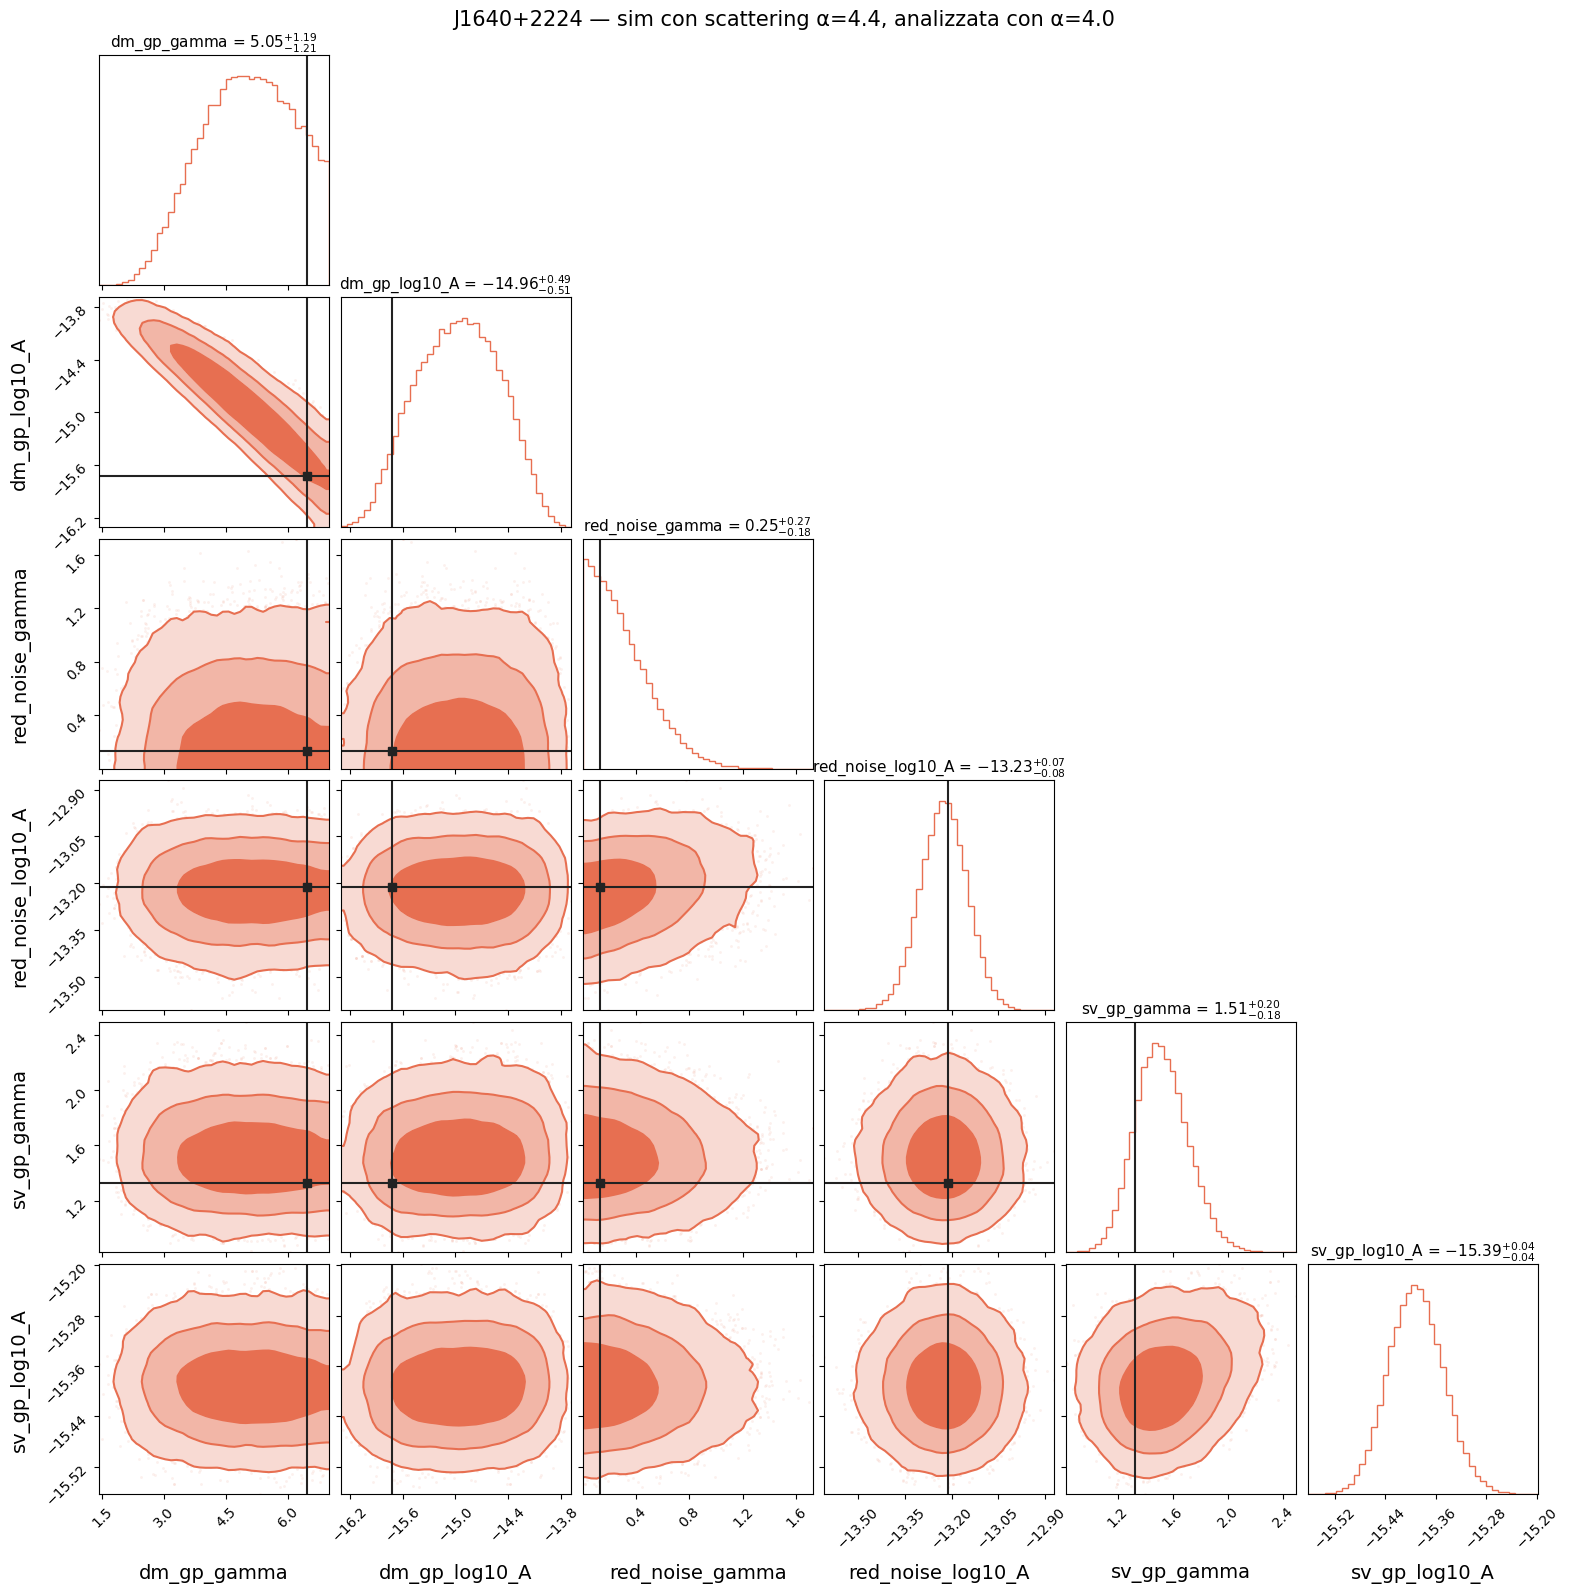

In [19]:
import corner

# valori veri iniettati
truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim_sv44.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_sv44.params]

fig = corner.corner(
    chain_sim_sv44,
    labels=clean_labels,
    truths=truth_values,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    truth_color='#222222',
    color='#E76F51',
)
fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim con scattering α=4.4, analizzata con α=4.0', fontsize=15, y=1.00)
fig.savefig('corner_sim_sv44.png', dpi=150, bbox_inches='tight')

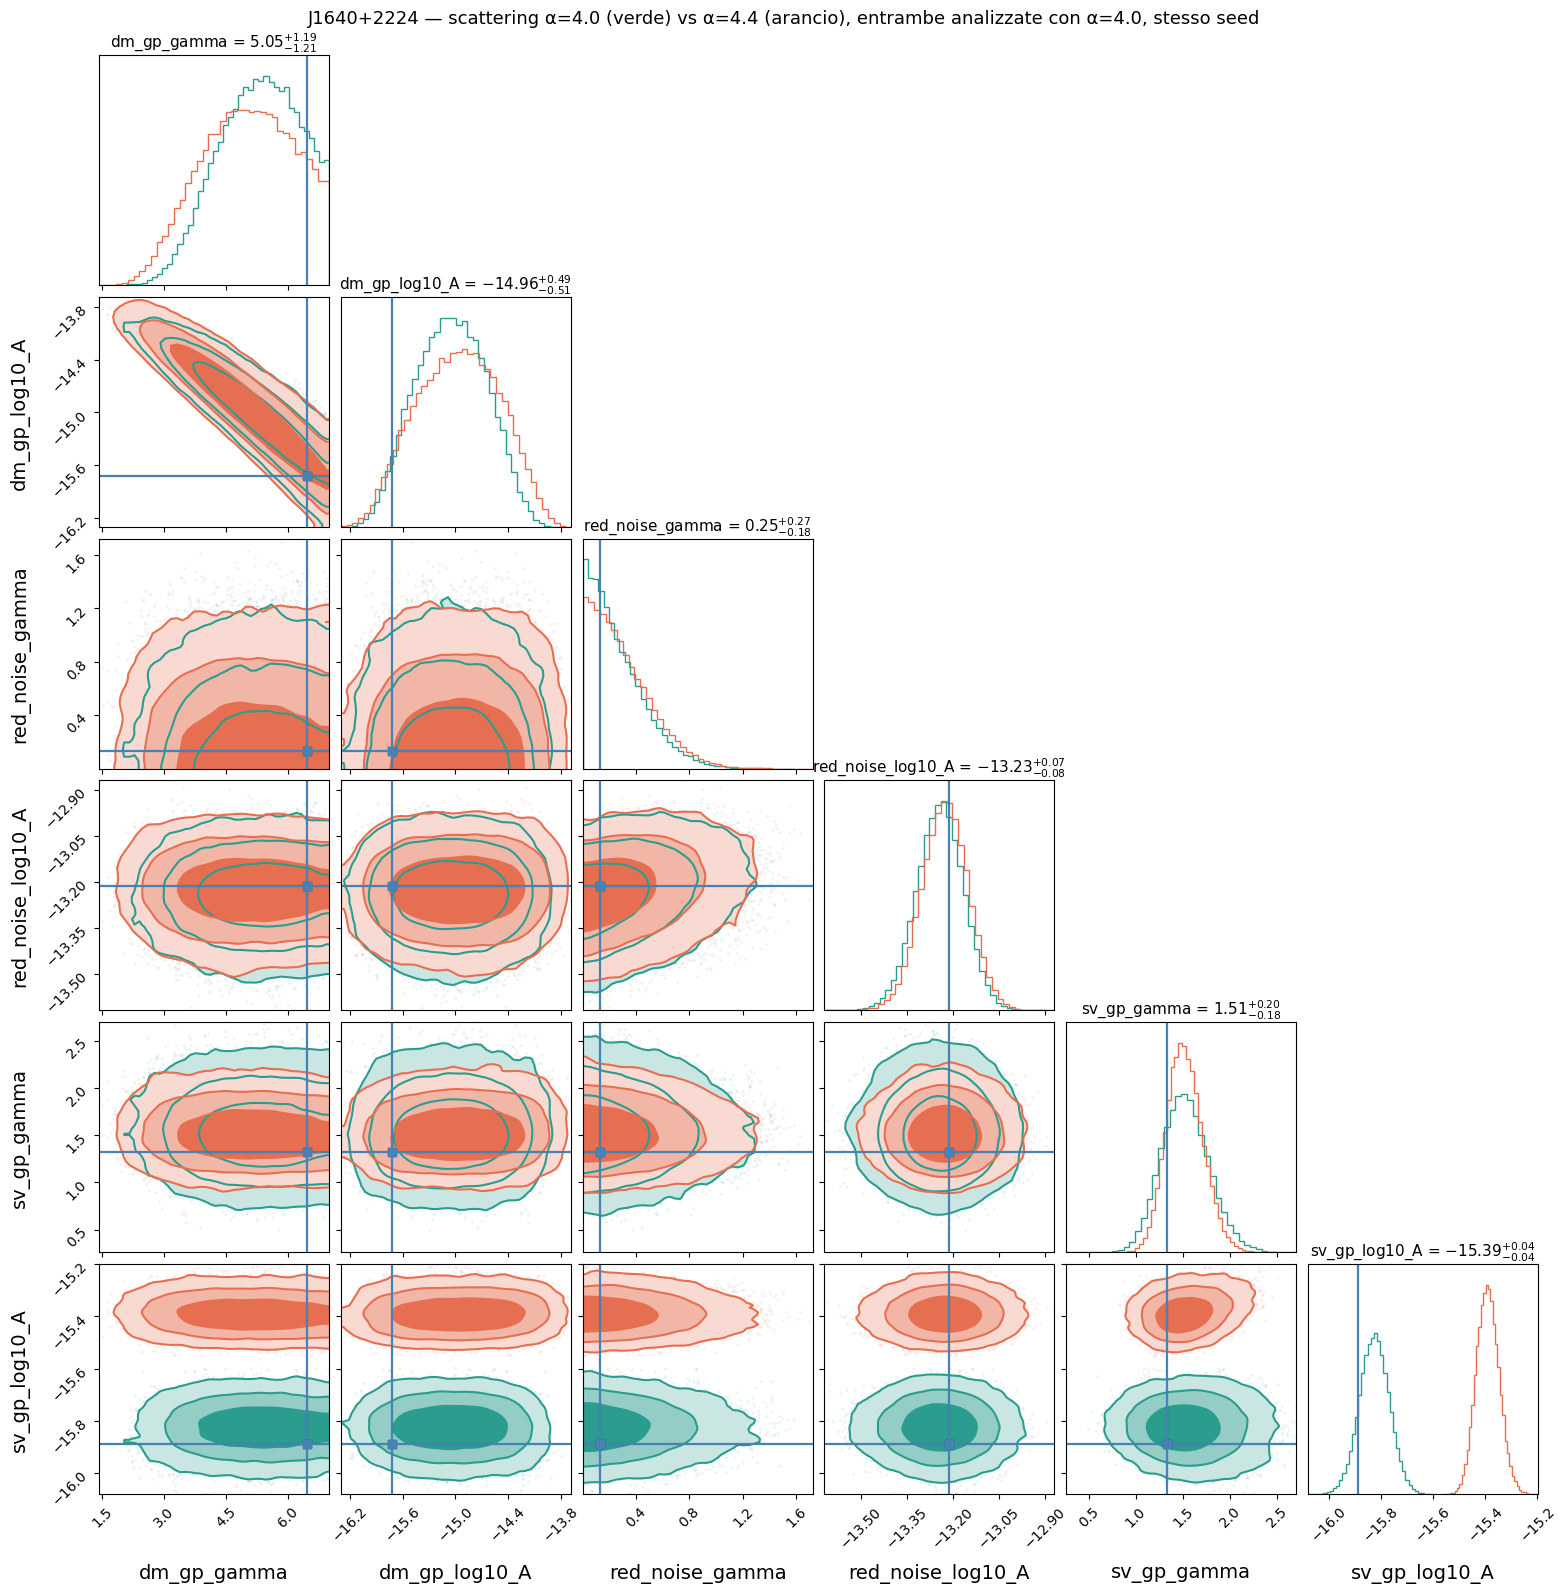

In [20]:
import corner

truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim_sv44.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_sv44.params]

# simulazione con alpha = 4.0 (modello corretto) — verde
fig = corner.corner(
    chain_sim,
    labels=clean_labels,
    truths=truth_values,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    truth_color='#222222',
    color='#2A9D8F',
)

# simulazione con alpha = 4.4 analizzata con 4.0 (modello errato) — arancio scuro
corner.corner(
    chain_sim_sv44,
    labels=clean_labels,
    truths=truth_values,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    color='#E76F51',
    fig=fig
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — scattering α=4.0 (verde) vs α=4.4 (arancio), entrambe analizzate con α=4.0, stesso seed',
             fontsize=13, y=1.00)
fig.savefig('corner_sim_alpha40_vs_sv44.png', dpi=150, bbox_inches='tight')

In [3]:
chain = np.loadtxt('./test/chain_1.txt')[:, :-4]
chain = chain[len(chain) // 4:]   # rimuovo il 25% di burn-in
chain.shape

(75001, 6)

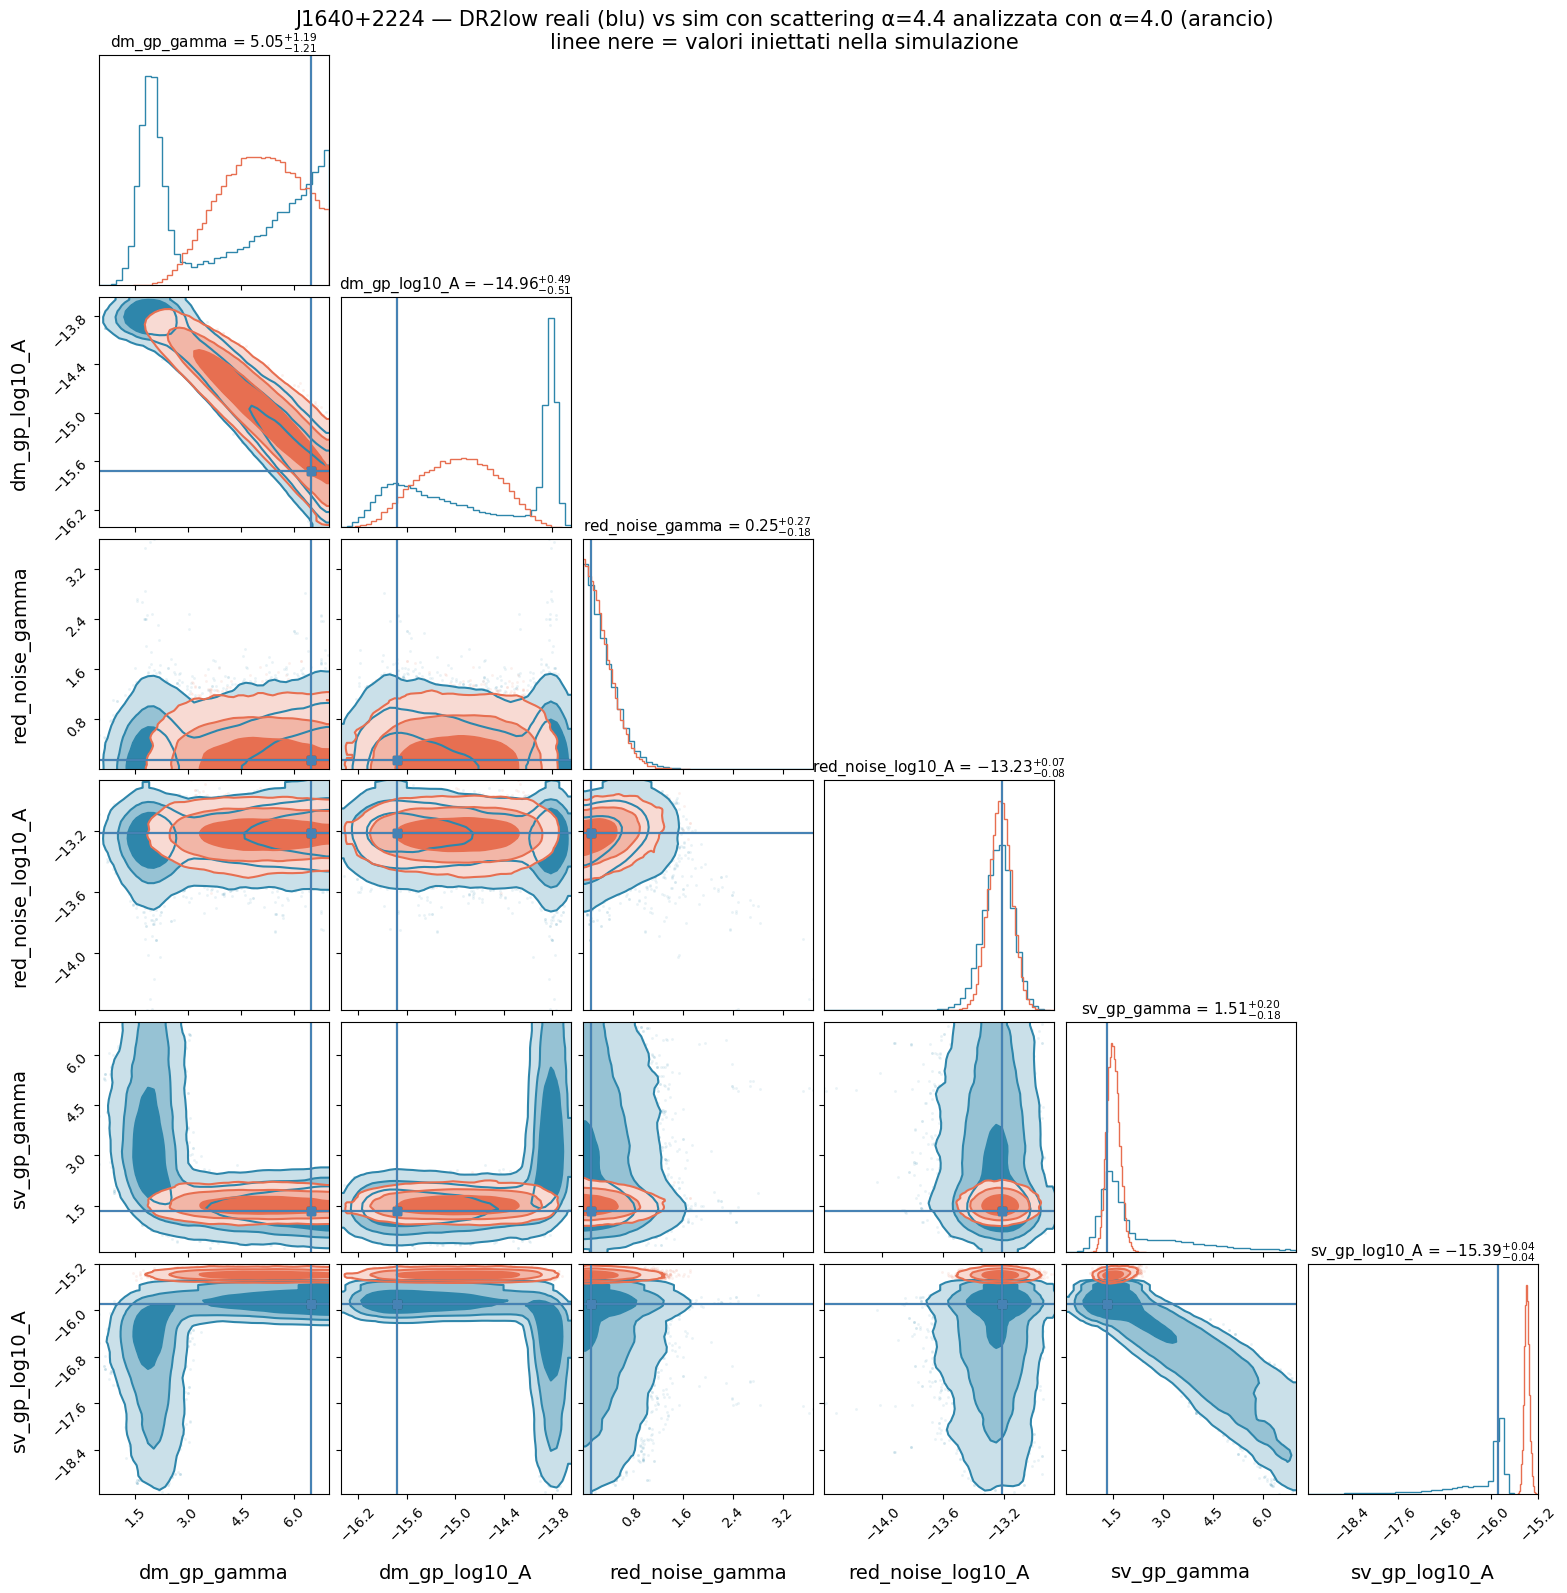

In [15]:
import corner

truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# dati reali DR2low — blu
fig = corner.corner(
    chain,
    labels=clean_labels,
    truths=truth_values,
    truth_color='#222222',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    color='#2E86AB',
)

# simulazione con scattering α=4.4, analizzata con α=4.0 — arancio scuro
corner.corner(
    chain_sim_sv44,
    labels=clean_labels,
    truths=truth_values,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    color='#E76F51',
    fig=fig
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — DR2low reali (blu) vs sim con scattering α=4.4 analizzata con α=4.0 (arancio)\n'
             'linee nere = valori iniettati nella simulazione',
             fontsize=15, y=1.00)
fig.savefig('corner_reali_vs_sim_sv44.png', dpi=150, bbox_inches='tight')

dati reali alfa = 4.4 nella likelihood 